# 🎯 Objetivo del notebook

Utilizar técnicas de aprendizaje no supervisado (unsupervised learning) para identificar puntos potencialmente anómalos en la señal CCL, usando features derivadas como dCCL, estadísticas móviles, ratios, etc.

Nos enfocaremos en:
- Comparación visual y cuantitativa.
- Score de anomalía agregado al dataset.

## 🚨 Detección de Anomalías en CCL con Machine Learning

En este notebook aplicamos modelos no supervisados para detectar comportamientos anómalos en la señal CCL.

Modelos utilizados:
- Isolation Forest
- One-Class SVM
- Local Outlier Factor (LOF)
- KNN (distancia a vecinos)

Usamos los features generados en la etapa anterior como entrada para los modelos.


### 💻 Celda 2 - Carga de datos enriquecidos

In [104]:
import pandas as pd
import numpy as np

# Cargamos el dataset con features ya generadas
df = pd.read_csv(r"C:\Developer\fundamentos\data\ccl_features.csv")

# Verificamos columnas disponibles
df.columns

Index(['DEPT', 'CCL', 'TENS', 'archivo_origen', 'pozo', 'sentido', 'etapa',
       'CCL_norm', 'dCCL', 'abs_dCCL', 'CCL_roll_mean_5', 'CCL_roll_std_5',
       'CCL_roll_max_5', 'CCL_roll_min_5', 'CCL_roll_mean_10',
       'CCL_roll_std_10', 'CCL_roll_max_10', 'CCL_roll_min_10',
       'ratio_to_mean5', 'ratio_to_std5', 'CCL_norm_mean', 'CCL_norm_std',
       'CCL_norm_max', 'CCL_norm_min', 'abs_dCCL_mean', 'abs_dCCL_std',
       'abs_dCCL_max', 'TENS_mean', 'TENS_std', 'TENS_max'],
      dtype='object')

### 🧽 Celda 3 - Selección y limpieza de features numéricas

#### 🧼 Selección de variables numéricas para modelar

Eliminamos columnas categóricas y trabajamos solo con features numéricas.

In [105]:
from sklearn.preprocessing import StandardScaler

# Excluimos columnas categóricas y de ID
drop_cols = ['DEPT', 'pozo', 'archivo_origen', 'sentido']
features = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Eliminamos también la columna original de CCL si está duplicada
features = features.select_dtypes(include=np.number).dropna()

# Verificar dimensiones antes de procesar
print("Dimensiones originales del DataFrame:", df.shape)
print("Dimensiones de features:", features.shape)

# Asegurarse que no hay NaN
features = features.dropna()
# Resetear el índice después de dropna
features = features.reset_index(drop=True)
df = df.loc[features.index].reset_index(drop=True)

# Verificar nuevamente
print("Nuevas dimensiones del DataFrame:", df.shape)
print("Nuevas dimensiones de features:", features.shape)

# Escalar los datos
scaler = StandardScaler()
X = scaler.fit_transform(features)



# Escalamos los datos
scaler = StandardScaler()
X = scaler.fit_transform(features)

Dimensiones originales del DataFrame: (13500, 30)
Dimensiones de features: (13499, 25)
Nuevas dimensiones del DataFrame: (13499, 30)
Nuevas dimensiones de features: (13499, 25)


### 🤖 Celda 4 - Modelos de anomalías (Isolation Forest, LOF, etc.)

#### 🧠 Modelos de detección de anomalías

Aplicamos distintos modelos para comparar su capacidad de encontrar puntos atípicos.


In [106]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from pyod.models.knn import KNN

# Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
df["anomaly_iso"] = iso_forest.fit_predict(X)
df["score_iso"] = iso_forest.decision_function(X) * -1  # invertir para que valores altos sean más anómalos

# One-Class SVM
ocsvm = OneClassSVM(kernel="rbf", nu=0.02, gamma="scale")
df["anomaly_svm"] = ocsvm.fit_predict(X)

# Local Outlier Factor (no permite predicción futura)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
df["anomaly_lof"] = lof.fit_predict(X)

# KNN (distancia al k-ésimo vecino más cercano)
knn = KNN()
knn.fit(X)
df["score_knn"] = knn.decision_scores_
df["anomaly_knn"] = knn.labels_


### 📊 Celda 5 - Visualización básica de scores

#### 📈 Visualización de scores de anomalía (Isolation Forest)

Graficamos el score a lo largo de la profundidad para identificar zonas anómalas en runs.


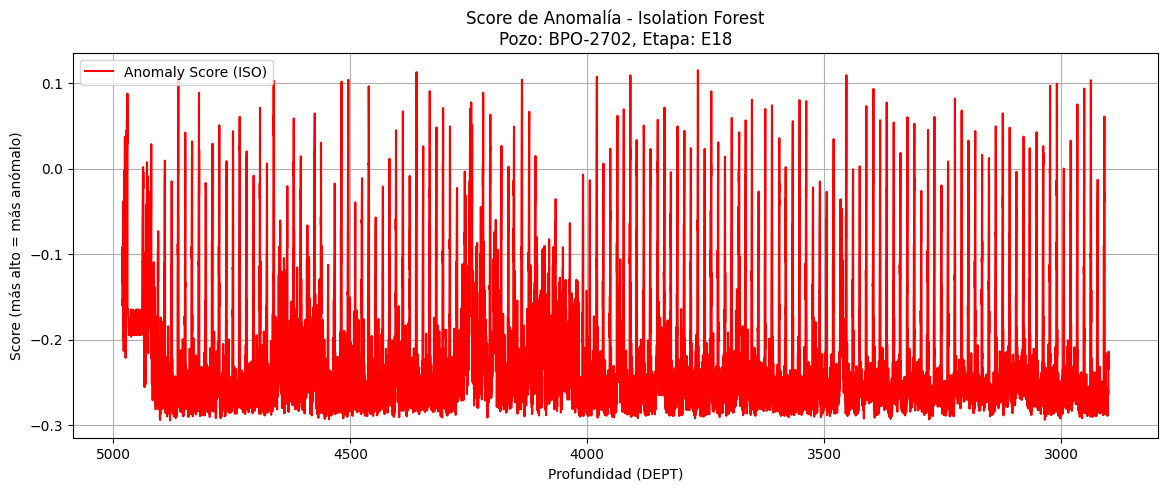

In [107]:
# Seleccionamos una corrida ejemplo
pozo_sample = df["pozo"].unique()[0]
etapa_sample = df[df["pozo"] == pozo_sample]["etapa"].unique()[0]

df_sample = df[(df["pozo"] == pozo_sample) & (df["etapa"] == etapa_sample)]

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_sample["DEPT"], df_sample["score_iso"], label="Anomaly Score (ISO)", color="red")
plt.gca().invert_xaxis()
plt.title(f"Score de Anomalía - Isolation Forest\nPozo: {pozo_sample}, Etapa: {etapa_sample}")
plt.xlabel("Profundidad (DEPT)")
plt.ylabel("Score (más alto = más anómalo)")
plt.grid()
plt.legend()
plt.show()


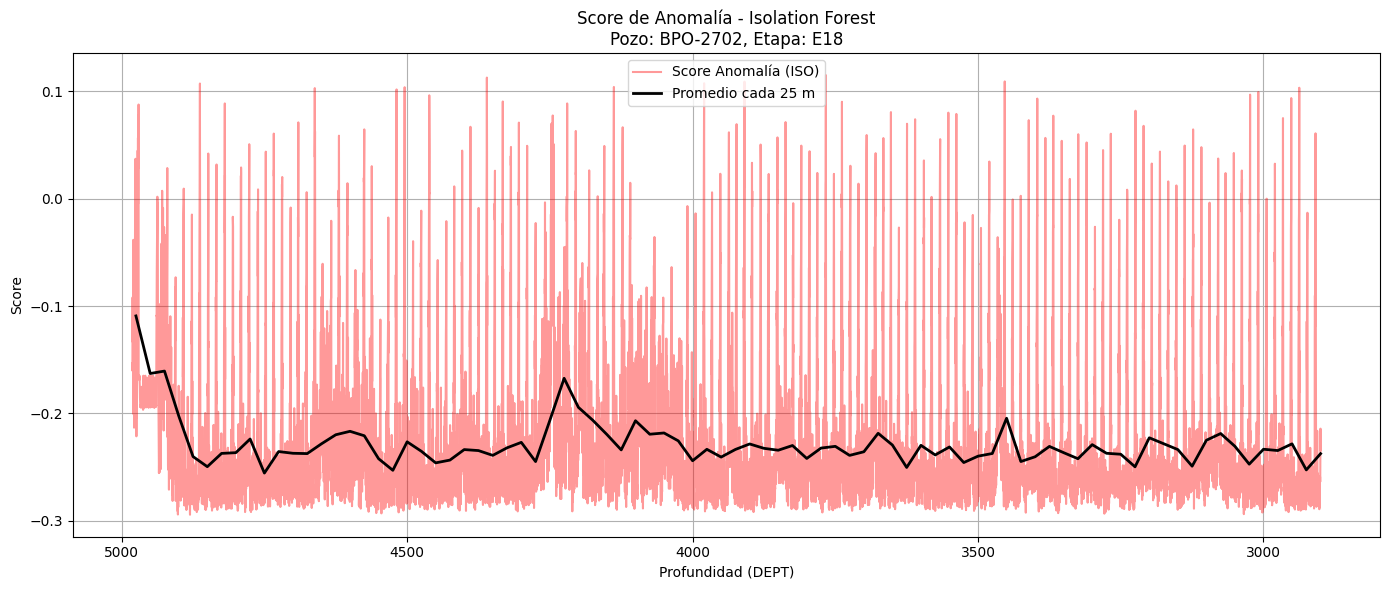

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# Selección de pozo y etapa
pozo_sample = df["pozo"].unique()[0]
etapa_sample = df[df["pozo"] == pozo_sample]["etapa"].unique()[0]

df_sample = df[(df["pozo"] == pozo_sample) & (df["etapa"] == etapa_sample)].copy()
df_sample = df_sample.sort_values(by="DEPT")

# 1. Score crudo
plt.figure(figsize=(14, 6))
plt.plot(df_sample["DEPT"], df_sample["score_iso"], label="Score Anomalía (ISO)", color="red", alpha=0.4)

# 2. Agrupar por tramos de 50 metros
step = 25
df_sample["DEPT_bin"] = (df_sample["DEPT"] // step) * step
df_grouped = df_sample.groupby("DEPT_bin")["score_iso"].mean().reset_index()

# 3. Graficar score medio por tramo (línea o puntos)
plt.plot(df_grouped["DEPT_bin"], df_grouped["score_iso"], label="Promedio cada 25 m", color="black", linewidth=2)

# Estética
plt.gca().invert_xaxis()
plt.title(f"Score de Anomalía - Isolation Forest\nPozo: {pozo_sample}, Etapa: {etapa_sample}")
plt.xlabel("Profundidad (DEPT)")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 💾 Celda 6 - Guardado del dataset con anomalías

#### 💾 Exportación de resultados

Guardamos el dataset enriquecido con los scores de anomalía para análisis posterior.


In [110]:
df.to_csv(r"C:\Developer\fundamentos\data\ccl_anomaly_scores.csv", index=False)


### ✅ Celda 7 - Conclusiones y próximos pasos

#### ✅ Conclusiones

- Se aplicaron 4 modelos distintos de detección de anomalías a partir de features ingenierizados.
- El `Isolation Forest` y el `KNN` nos permiten obtener un **score continuo**, útil para priorizar eventos posibles de deformación de casing.
- En siguientes fases, se puede comparar estos resultados contra runs históricas con eventos reales (si los hay) o incorporar feedback de expertos.
- También puede usarse este modelo en un loop de **detección por etapa o en tiempo cuasi real**, como en el paper original.

**Próximo paso sugerido**: visualización interactiva por etapa con `plotly` o exportar los resultados a una app `Streamlit` para revisar junto al equipo operativo.
